Device:  cuda
AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)
Epoch: [1/10], Loss: 28.4822
Epoch: [2/10], Loss: 15.0223
Epoch: [3/10], Loss: 12.2658
Epoch: [4/10], Loss: 11.1107
Epoch: [5/10], Loss: 10.3520
Epoch: [6/10], Loss: 9.8860
Epoch: [7/10], Loss: 9.5584
Epoch: [8/10], Loss: 9.2963
Epoch: [9/10], Loss: 9.0907
Epoch: [10/10], Loss: 8.9036


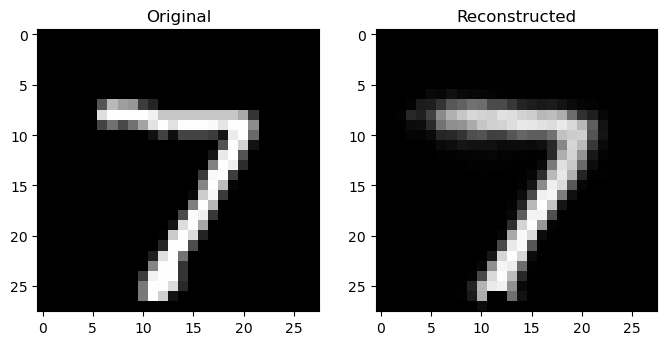

In [ ]:
#Q1

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ",device)

transform=transforms.ToTensor()

train_dataset=datasets.MNIST(root='./data',train=True,transform=transform,download=True)
test_dataset=datasets.MNIST(root='./data',train=False, transform=transform)

train_loader=DataLoader(train_dataset,batch_size=128,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=128,shuffle=False)

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder=nn.Sequential(
            nn.Linear(784,128), #Img--> 28x28=784
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
        self.decoder=nn.Sequential(
            nn.Linear(10,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,784),
            nn.Sigmoid()
        )
    def forward(self,x):
        z=self.encoder(x) #encoder op
        x_hat=self.decoder(z) #decoder op
        return x_hat,z

model=AutoEncoder().to(device)
print(model)

criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=1e-3)

epochs=10
for epoch in range(epochs):
    total_loss=0
    for img,label in train_loader:
        img=img.view(-1,784).to(device) #(128, 1, 28, 28) -> (128, 784)
        x_hat,z=model(img)

        loss=criterion(x_hat,img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
    print(f"Epoch: [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")

model.eval()
with torch.no_grad():
    img,_=next(iter(test_loader))
    img=img.view(-1,784).to(device)

    reconstructed, _=model(img)

    img=img.view(-1,1,28,28)
    reconstructed=reconstructed.view(-1,1,28,28)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0].cpu().squeeze(),cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(reconstructed[0].cpu().squeeze(),cmap="gray")
plt.title("Reconstructed")

plt.show()

Device:  cuda
Epoch [1/10], Loss: 9861016.14
Epoch [2/10], Loss: 7297377.93
Epoch [3/10], Loss: 6870826.19
Epoch [4/10], Loss: 6683493.81
Epoch [5/10], Loss: 6575598.64
Epoch [6/10], Loss: 6506792.34
Epoch [7/10], Loss: 6452931.41
Epoch [8/10], Loss: 6414898.47
Epoch [9/10], Loss: 6382659.53
Epoch [10/10], Loss: 6358691.88


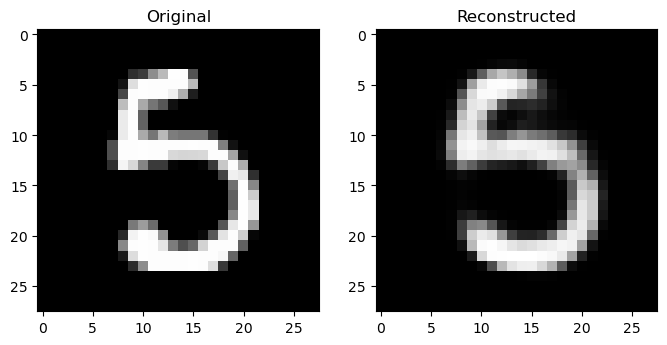

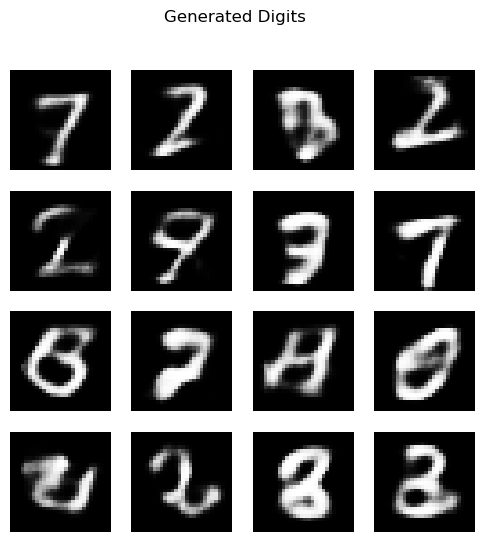

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device: ",device)

transform=transforms.ToTensor()

train_dataset=datasets.MNIST(root='./data', train=True, transform=transform,download=True)
train_loader=DataLoader(train_dataset,batch_size=128,shuffle=True)

class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder=nn.Sequential(
            nn.Linear(784,400),
            nn.ReLU()
        )

        self.fc_mu=nn.Linear(400,20) #mean
        self.fc_logvar=nn.Linear(400,20) #variance

        self.decoder=nn.Sequential(
            nn.Linear(20,400),
            nn.ReLU(),
            nn.Linear(400,784),
            nn.Sigmoid()
        )
    def reparameterize(self,mu,logvar):
        std=torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu+eps*std
    def forward(self,x):
        x=self.encoder(x)
        mu=self.fc_mu(x)
        logvar=self.fc_logvar(x)
        z=self.reparameterize(mu,logvar)
        x_hat=self.decoder(z)
        return x_hat,mu,logvar
    
def loss_function(x, x_hat, mu, logvar):
    # Reconstruction loss
    BCE = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')

    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return BCE + KLD

model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    total_loss = 0

    for img, _ in train_loader:
        img = img.view(-1, 784).to(device)

        x_hat, mu, logvar = model(img)

        loss = loss_function(img, x_hat, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.2f}")

model.eval()
with torch.no_grad():
    img, _ = next(iter(train_loader))
    img = img.view(-1, 784).to(device)

    reconstructed, _, _ = model(img)

    img = img.view(-1,1,28,28)
    reconstructed = reconstructed.view(-1,1,28,28)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img[0].cpu().squeeze(), cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(reconstructed[0].cpu().squeeze(), cmap='gray')
plt.title("Reconstructed")

plt.show()

with torch.no_grad():
    z = torch.randn(16, 20).to(device)  # sample from latent space
    generated = model.decoder(z)
    generated = generated.view(-1,1,28,28)

plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Digits")
plt.show()